# Parcial 1 — Inteligencia Artificial
## Predicción de la calidad del agua con una red neuronal implementada desde cero


**Dataset:** [Water Quality Data — Kaggle](https://www.kaggle.com/datasets/supriyoain/water-quality-data/data)

---

### Problema

A partir de mediciones fisicoquímicas y biológicas de muestras de agua queremos responder dos cosas:

1. **¿Qué características hacen que se afecte la calidad del agua?** (análisis exploratorio, EDA)
2. **¿Podemos predecir la calidad de una muestra nueva?** (red neuronal entrenada desde cero)

### Restricciones del parcial y cómo las cumplimos

| Requisito | Dónde se cumple |
|---|---|
| EDA con preguntas, hipótesis, gráficas y medidas estadísticas | Secciones 2 y 3 |
| Gráfico de la arquitectura indicando la activación de cada capa/neurona | Sección 5 |
| Red neuronal **sin librerías de ML** | Sección 6 (`RedNeuronal`, solo NumPy) |
| Justificación del algoritmo de aprendizaje | Sección 6.1 y Anexo A |
| División 80% entrenamiento / 20% validación | Sección 4.2 (`dividir_entrenamiento_prueba`, estratificada) |
| Evaluación (meta: accuracy ≥ 80%) | Sección 8 |
| Informe con conclusiones | Este notebook + Sección 10 |

> **Sobre las librerías.** Usamos `numpy` únicamente como calculadora de álgebra lineal (multiplicación de
> matrices), `pandas` para leer el CSV y `matplotlib`/`seaborn` para graficar. **No se usa ninguna librería de
> machine learning**: la propagación hacia adelante, el *backpropagation*, el optimizador, la partición de los
> datos, la estandarización y todas las métricas (accuracy, precisión, recall, F1, matriz de confusión, ROC-AUC)
> están programadas a mano en este notebook. Se puede verificar: no hay un solo `import sklearn`,
> `tensorflow`, `keras`, `torch` ni `scipy`.

## 1. Configuración, carga y saneamiento de los datos

In [ ]:
# ÚNICAS dependencias: álgebra lineal, manejo de tablas y gráficas.
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Reproducibilidad ---------------------------------------------------------
SEMILLA = 42
rng = np.random.default_rng(SEMILLA)

# --- Estética de las gráficas -------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.autolayout"] = True
PALETA = {"neg": "#4C72B0", "pos": "#DD8452"}

# --- Parámetros del experimento ----------------------------------------------
RUTA_CSV = None        # None -> descarga desde Kaggle; si no, ruta local al CSV o a su carpeta
COL_OBJETIVO = None    # None -> detecta automáticamente la columna de calidad
PROP_ENTRENAMIENTO = 0.80

print("NumPy:", np.__version__, "| pandas:", pd.__version__)

NumPy: 2.1.3 | pandas: 2.2.3


### 1.1 Descarga y lectura del dataset

Igual que en el Taller 01, descargamos el dataset directamente desde Kaggle con `kagglehub`, así el
notebook funciona en Google Colab sin subir archivos a mano. Si la descarga falla (sin internet, sin
credenciales o ejecutando en local), busca automáticamente un `.csv` en la carpeta actual.

> Si Kaggle pide credenciales: en Colab, panel izquierdo → 🔑 *Secrets* → agregar `KAGGLE_USERNAME` y
> `KAGGLE_KEY` (se obtienen en kaggle.com → *Settings* → *Create New Token*). También sirve subir el
> `kaggle.json` o, como último recurso, subir el CSV con la celda opcional de más abajo.

In [ ]:
# En Colab esta instalación es necesaria; en local, solo la primera vez.
!pip install -q kagglehub

In [ ]:
DATASET_KAGGLE = "supriyoain/water-quality-data"


def listar_tablas(carpeta):
    """Todos los archivos tabulares dentro de una carpeta (incluidas subcarpetas)."""
    encontrados = []
    for raiz, _, archivos in os.walk(carpeta):
        for a in archivos:
            if a.lower().endswith((".csv", ".tsv", ".xlsx")):
                encontrados.append(os.path.join(raiz, a))
    return sorted(encontrados)


def leer_tabla(ruta):
    if ruta.lower().endswith(".xlsx"):
        return pd.read_excel(ruta)
    if ruta.lower().endswith(".tsv"):
        return pd.read_csv(ruta, sep="\t")
    return pd.read_csv(ruta)


def obtener_archivos(ruta_manual=None, slug=DATASET_KAGGLE):
    """Devuelve la lista de archivos de datos: primero Kaggle, luego búsqueda local."""
    if ruta_manual is not None:
        if not os.path.exists(ruta_manual):
            raise FileNotFoundError(f"No existe la ruta indicada: {ruta_manual}")
        return listar_tablas(ruta_manual) if os.path.isdir(ruta_manual) else [ruta_manual]

    try:
        import kagglehub
        carpeta = kagglehub.dataset_download(slug)
        print("Descargado desde Kaggle en:", carpeta)
        archivos = listar_tablas(carpeta)
        if archivos:
            return archivos
        print("La descarga no contiene archivos tabulares; se busca en local.")
    except Exception as e:
        print(f"No se pudo descargar desde Kaggle ({type(e).__name__}: {e}).")
        print("Se busca un archivo local...")

    locales = []
    for carpeta in [".", "data", "datos", "/content", "/content/sample_data"]:
        if os.path.isdir(carpeta):
            locales.extend(listar_tablas(carpeta))
    # Excluimos archivos que genera este mismo notebook y damos prioridad a los que
    # se llaman como el dataset, para no tomar por error un archivo de resultados.
    generados = {"predicciones_validacion.csv"}
    locales = [f for f in locales
               if "sample_data" not in f and os.path.basename(f) not in generados]
    preferidos = [f for f in locales
                  if any(k in os.path.basename(f).lower()
                         for k in ("water", "quality", "agua", "calidad"))]
    locales = preferidos or locales
    if not locales:
        raise FileNotFoundError(
            "No se encontró ningún archivo de datos.\n"
            "Opciones:\n"
            "  1) Configurar las credenciales de Kaggle (ver la nota de arriba) y reejecutar.\n"
            "  2) Descargar el CSV de "
            "https://www.kaggle.com/datasets/supriyoain/water-quality-data/data y subirlo\n"
            "     con la celda opcional de la sección 1.1, o dejarlo junto a este notebook.\n"
            "  3) Fijar RUTA_CSV con la ruta del archivo."
        )
    return locales


archivos = obtener_archivos(RUTA_CSV)
print(f"\nArchivos encontrados ({len(archivos)}):")
partes = []
for f in archivos:
    tmp = leer_tabla(f)
    print(f"  - {os.path.basename(f):<40} {tmp.shape}")
    tmp["archivo_origen"] = os.path.basename(f)
    partes.append(tmp)

# Si el dataset viene repartido en varios archivos con las mismas columnas, se concatenan;
# si tienen estructuras distintas, se usa el más grande y se avisa.
if len(partes) == 1:
    crudo = partes[0].drop(columns=["archivo_origen"])
else:
    firmas = {tuple(sorted(p.columns)) for p in partes}
    if len(firmas) == 1:
        crudo = pd.concat(partes, ignore_index=True)
        print("\nLos archivos comparten columnas: se concatenan en una sola tabla.")
    else:
        crudo = max(partes, key=len).drop(columns=["archivo_origen"])
        print("\nLos archivos tienen estructuras distintas: se usa el más grande.")

# La columna de procedencia solo sirve si aporta información; nunca como predictora.
if "archivo_origen" in crudo.columns and crudo["archivo_origen"].nunique() <= 1:
    crudo = crudo.drop(columns=["archivo_origen"])

print(f"\nDimensiones del dataset: {crudo.shape[0]} filas x {crudo.shape[1]} columnas")
crudo.head()

Using Colab cache for faster access to the 'water-quality-data' dataset.
Descargado desde Kaggle en: /kaggle/input/water-quality-data

Archivos encontrados (1):
  - waterquality.csv                         (2371, 8)

Dimensiones del dataset: 2371 filas x 8 columnas


,Date,Salinity (ppt),DissolvedOxygen (mg/L),pH,SecchiDepth (m),WaterDepth (m),WaterTemp (C),AirTemp (C)
0,1989-05-11,NaN,NaN,7.5,0.3,0.9,17.0,-17.777778
1,1989-05-18,NaN,12.0,7.5,0.2,0.6,17.5,20.500000
2,1989-05-25,NaN,NaN,8.0,0.4,0.8,23.0,25.000000
3,1989-06-01,NaN,12.0,8.0,0.4,0.9,25.5,29.000000
4,1989-07-11,NaN,NaN,8.5,0.3,0.9,28.5,28.000000


In [ ]:
# Tipos de dato y valores faltantes tal como vienen del archivo.
resumen_inicial = pd.DataFrame({
    "tipo": crudo.dtypes.astype(str),
    "no_nulos": crudo.notna().sum(),
    "nulos": crudo.isna().sum(),
    "valores_unicos": crudo.nunique(),
})
resumen_inicial

,tipo,no_nulos,nulos,valores_unicos
Date,object,2366,5,801
Salinity (ppt),float64,2241,130,61
DissolvedOxygen (mg/L),float64,1520,851,154
pH,float64,2276,95,48
SecchiDepth (m),float64,2298,73,77
WaterDepth (m),float64,2300,71,114
WaterTemp (C),float64,2250,121,114
AirTemp (C),float64,2371,0,226


### 1.2 Identificación de la variable objetivo (la "calidad")

Buscamos la columna que codifica la calidad del agua. Los nombres habituales en estos datasets son
`is_safe`, `Potability`, `quality`, `target` o `class`; si ninguno aparece, se usa la última columna,
que es la convención en archivos de clasificación.

In [ ]:
NOMBRES_OBJETIVO = ["is_safe", "issafe", "safe", "safety", "potability", "potable",
                    "quality", "water_quality", "calidad", "target", "class", "label"]


def detectar_objetivo(df, col=None):
    if col is not None:
        return col
    normalizados = {c.strip().lower().replace(" ", "_"): c for c in df.columns}
    for nombre in NOMBRES_OBJETIVO:
        if nombre in normalizados:
            return normalizados[nombre]
    return df.columns[-1]


OBJETIVO = detectar_objetivo(crudo, COL_OBJETIVO)
print(f"Variable objetivo detectada: '{OBJETIVO}'")
print("\nValores que toma (top 10):")
print(crudo[OBJETIVO].value_counts(dropna=False).head(10))

Variable objetivo detectada: 'AirTemp (C)'

Valores que toma (top 10):
AirTemp (C)
 8.888889     85
-17.777778    71
 21.111111    66
 26.666667    66
 22.222222    63
 14.444444    59
 15.555556    58
 7.222222     58
 25.555556    55
 27.777778    55
Name: count, dtype: int64


### 1.3 Saneamiento

Tres problemas típicos de este dataset, y cómo los tratamos:

1. **Valores centinela de Excel** (`#NUM!`, `#DIV/0!`, `?`, `-`): convertimos toda columna numérica con
   `errors="coerce"`, de modo que esos textos se vuelven `NaN` en lugar de forzar la columna a tipo texto.
2. **Columnas no numéricas** (identificadores, fechas): las de alta cardinalidad se descartan porque no
   aportan señal generalizable; las categóricas de baja cardinalidad se codifican *one-hot*.
3. **Filas duplicadas y filas sin etiqueta**: se eliminan. Una fila sin etiqueta no sirve ni para entrenar
   ni para validar.

**Importante:** aquí *no* imputamos valores faltantes todavía. La imputación se hace después de partir los
datos, usando únicamente estadísticos del conjunto de entrenamiento, para no filtrar información del
conjunto de validación (*data leakage*).

In [ ]:
df = crudo.copy()
df.columns = [c.strip() for c in df.columns]
OBJETIVO = OBJETIVO.strip()

# 1) Texto -> número donde sea posible (los centinelas quedan como NaN).
def es_texto(serie):
    """True si la columna no es numérica. Compatible con pandas 2.x (object) y 3.x (str dtype)."""
    return not pd.api.types.is_numeric_dtype(serie)


convertidas = []
for c in df.columns:
    if es_texto(df[c]):
        conv = pd.to_numeric(df[c].astype(str).str.strip(), errors="coerce")
        # Si al menos el 80% de los valores no nulos se convirtió, la columna era numérica "sucia".
        no_nulos_orig = df[c].notna().sum()
        if no_nulos_orig > 0 and conv.notna().sum() >= 0.8 * no_nulos_orig:
            df[c] = conv
            convertidas.append(c)
if convertidas:
    print("Columnas de texto convertidas a numéricas:", convertidas)

# 2) Filas duplicadas y filas sin etiqueta.
n0 = len(df)
df = df.drop_duplicates()
n1 = len(df)
df = df[df[OBJETIVO].notna()].copy()
n2 = len(df)
print(f"Duplicados eliminados: {n0 - n1} | Filas sin etiqueta eliminadas: {n1 - n2}")

# 3) Columnas categóricas restantes.
categoricas = [c for c in df.columns if c != OBJETIVO and es_texto(df[c])]
descartadas, codificadas = [], []
for c in categoricas:
    if df[c].nunique() <= 10:
        codificadas.append(c)
    else:
        descartadas.append(c)
if descartadas:
    df = df.drop(columns=descartadas)
    print("Columnas de texto descartadas (alta cardinalidad / identificadores):", descartadas)
if codificadas:
    df = pd.get_dummies(df, columns=codificadas, drop_first=True, dtype=float)
    print("Columnas categóricas codificadas one-hot:", codificadas)

print(f"\nDimensiones tras el saneamiento: {df.shape[0]} filas x {df.shape[1]} columnas")

Duplicados eliminados: 10 | Filas sin etiqueta eliminadas: 0
Columnas de texto descartadas (alta cardinalidad / identificadores): ['Date']

Dimensiones tras el saneamiento: 2361 filas x 7 columnas


### 1.4 Definición de las clases

El objetivo del parcial es **clasificar la calidad**. Si la columna objetivo ya es categórica
(por ejemplo `is_safe` ∈ {0, 1}) la usamos tal cual. Si fuera continua (un índice de calidad),
la discretizamos por la mediana en *calidad baja* vs *calidad alta*, y lo dejamos documentado.

In [ ]:
y_serie = df[OBJETIVO]
valores_unicos = np.sort(y_serie.dropna().unique())

def etiqueta_legible(v):
    try:
        return str(int(v)) if float(v).is_integer() else f"{float(v):.3g}"
    except (TypeError, ValueError):
        return str(v)


if len(valores_unicos) <= 10:
    y_cod = y_serie.map({v: i for i, v in enumerate(valores_unicos)}).astype(int).to_numpy()
    CLASES_ORIG = [etiqueta_legible(v) for v in valores_unicos]
    tipo_objetivo = "categórica (se usa tal cual)"
else:
    corte = float(y_serie.median())
    CLASES_ORIG = [f"<= {corte:.3g}", f"> {corte:.3g}"]
    y_cod = (y_serie > corte).astype(int).to_numpy()
    tipo_objetivo = f"continua -> discretizada por la mediana ({corte:.4g})"

NOMBRES_CLASE = [f"{OBJETIVO}={c}" for c in CLASES_ORIG]
if len(CLASES_ORIG) == 2:
    NOMBRES_CLASE = [f"No apta ({OBJETIVO}={CLASES_ORIG[0]})", f"Apta ({OBJETIVO}={CLASES_ORIG[1]})"]

N_CLASES = len(CLASES_ORIG)
CARACTERISTICAS = [c for c in df.columns if c != OBJETIVO]
X_todo = df[CARACTERISTICAS].astype(float).to_numpy()
y_todo = y_cod

print(f"Objetivo: {tipo_objetivo}")
print(f"Número de clases: {N_CLASES} -> {NOMBRES_CLASE}")
print(f"Número de características predictoras: {len(CARACTERISTICAS)}")
print(f"Muestras utilizables: {len(y_todo)}")

Objetivo: continua -> discretizada por la mediana (16.67)
Número de clases: 2 -> ['No apta (AirTemp (C)=<= 16.7)', 'Apta (AirTemp (C)=> 16.7)']
Número de características predictoras: 6
Muestras utilizables: 2361


## 2. Análisis exploratorio (EDA): preguntas e hipótesis

El EDA no es "hacer gráficas bonitas": es contestar preguntas concretas. Planteamos cinco preguntas con su
respectiva hipótesis, y cada una se resuelve más abajo con una medida estadística y una gráfica.

| # | Pregunta | Hipótesis | Cómo se resuelve |
|---|---|---|---|
| P1 | ¿Están balanceadas las clases de calidad? | H1: el dataset está desbalanceado; las muestras no aptas son mayoría, así que la *accuracy* sola será una métrica engañosa. | Conteo de clases + línea base del clasificador trivial (3.1) |
| P2 | ¿Hay datos faltantes o imposibles (negativos, centinelas) que sesguen el análisis? | H2: existen valores faltantes concentrados en pocas columnas; se pueden imputar sin perder filas. | Mapa de nulos y estadísticos descriptivos (3.2) |
| P3 | ¿Qué variables separan mejor el agua apta de la no apta? | H3: solo un subconjunto pequeño de contaminantes concentra la señal; el resto aporta poco. | Tamaño de efecto (η², d de Cohen) + prueba t de Welch (3.4) |
| P4 | ¿Las variables predictoras están correlacionadas entre sí? | H4: hay correlaciones moderadas entre contaminantes de origen común, pero no multicolinealidad extrema. | Matriz de correlación de Pearson (3.5) |
| P5 | ¿La relación entre cada variable y la calidad es lineal o por umbrales? | H5: la relación es **no lineal y por umbrales** (la toxicidad aparece al superar un límite), lo que justifica usar una red neuronal en lugar de un modelo lineal. | Probabilidad de ser apta por deciles de cada variable (3.6) |

> Estas hipótesis se **contrastan**, no se asumen: al final de la sección 3 se indica cuáles quedaron
> respaldadas por los datos y cuáles no.

## 3. EDA: resultados

### 3.1 P1 — Distribución de la variable objetivo

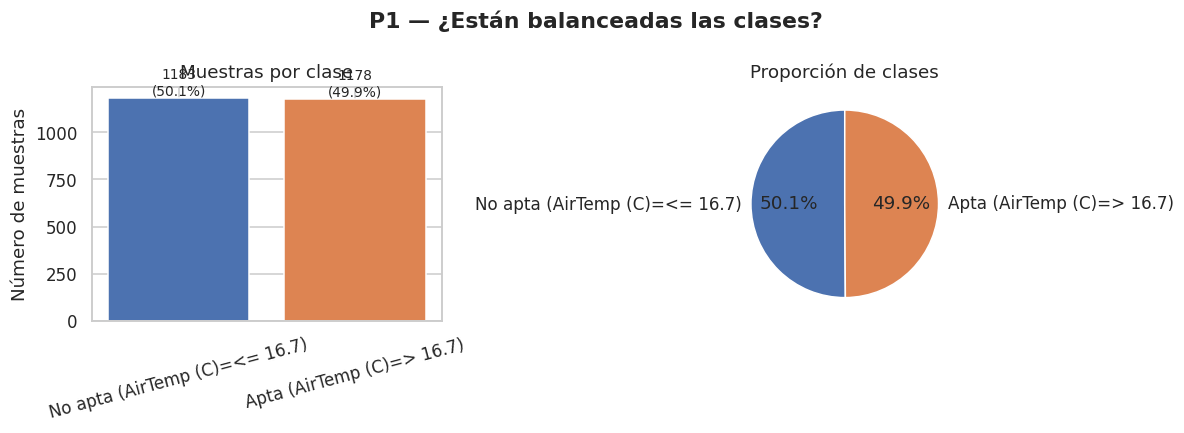

Clase mayoritaria: No apta (AirTemp (C)=<= 16.7)
LÍNEA BASE: un modelo que siempre responda la clase mayoritaria acierta el 50.11%.
=> Cualquier modelo debe superar ese número; por eso además de accuracy reportamos
   recall, F1 y accuracy balanceada (sección 8).


In [ ]:
COLORES = [PALETA["neg"], PALETA["pos"], "#55A868", "#C44E52", "#8172B3"]


def colores_clase(n):
    return [COLORES[i % len(COLORES)] for i in range(n)]


conteo = pd.Series(y_todo).value_counts().sort_index()
proporciones = conteo / conteo.sum()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar([NOMBRES_CLASE[i] for i in conteo.index], conteo.values,
            color=colores_clase(len(conteo)))
axes[0].set_title("Muestras por clase")
axes[0].set_ylabel("Número de muestras")
for i, v in enumerate(conteo.values):
    axes[0].text(i, v, f"{v}\n({v / conteo.sum():.1%})", ha="center", va="bottom", fontsize=9)
axes[0].tick_params(axis="x", labelrotation=15)

axes[1].pie(conteo.values, labels=[NOMBRES_CLASE[i] for i in conteo.index],
            autopct="%1.1f%%", colors=colores_clase(len(conteo)),
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Proporción de clases")
fig.suptitle("P1 — ¿Están balanceadas las clases?", fontweight="bold")
plt.show()

clase_mayoritaria = int(conteo.idxmax())
linea_base = proporciones.max()
print(f"Clase mayoritaria: {NOMBRES_CLASE[clase_mayoritaria]}")
print(f"LÍNEA BASE: un modelo que siempre responda la clase mayoritaria acierta el {linea_base:.2%}.")
print("=> Cualquier modelo debe superar ese número; por eso además de accuracy reportamos")
print("   recall, F1 y accuracy balanceada (sección 8).")

DESBALANCEADO = linea_base > 0.60

### 3.2 P2 — Calidad de los datos: faltantes y estadísticos descriptivos

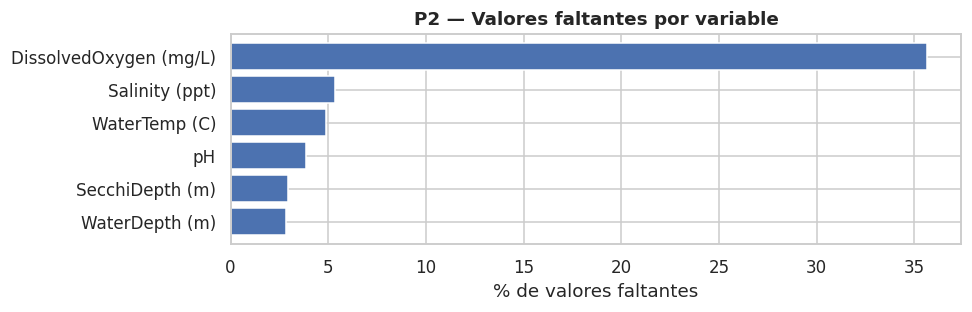

Total de valores faltantes: 1310

Estadísticos descriptivos (medidas de tendencia central y dispersión):


,count,mean,std,min,25%,50%,75%,max,mediana,rango_iq,asimetria,curtosis
Salinity (ppt),2235.0,0.718,1.231,0.00,0.0,0.000,1.00,9.0,0.000,1.00,1.973,4.274
DissolvedOxygen (mg/L),1520.0,6.646,2.507,0.00,4.8,6.500,8.50,15.1,6.500,3.70,0.185,-0.408
pH,2270.0,7.168,0.789,0.30,6.5,7.000,7.50,9.9,7.000,1.00,0.269,4.499
SecchiDepth (m),2292.0,0.525,0.474,0.00,0.3,0.400,0.65,9.0,0.400,0.35,7.057,88.855
WaterDepth (m),2294.0,0.763,0.622,0.01,0.4,0.665,0.95,12.0,0.665,0.55,6.191,77.986
WaterTemp (C),2245.0,18.052,8.300,0.00,11.0,19.000,25.00,74.0,19.000,14.00,0.140,0.416


In [ ]:
nulos = df[CARACTERISTICAS].isna().sum().sort_values(ascending=False)
nulos_pct = (nulos / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(9, max(3, 0.28 * len(CARACTERISTICAS))))
ax.barh(nulos.index[::-1], nulos_pct.values[::-1], color=PALETA["neg"])
ax.set_xlabel("% de valores faltantes")
ax.set_title("P2 — Valores faltantes por variable", fontweight="bold")
plt.show()

print("Total de valores faltantes:", int(nulos.sum()))
print("\nEstadísticos descriptivos (medidas de tendencia central y dispersión):")
descriptivos = df[CARACTERISTICAS].describe().T
descriptivos["mediana"] = df[CARACTERISTICAS].median()
descriptivos["rango_iq"] = descriptivos["75%"] - descriptivos["25%"]
descriptivos["asimetria"] = df[CARACTERISTICAS].skew()
descriptivos["curtosis"] = df[CARACTERISTICAS].kurt()
descriptivos.round(3)

La **asimetría** (*skewness*) es relevante: varias variables de concentración están sesgadas a la derecha
(muchas muestras con concentración baja y una cola de valores altos). Eso refuerza la decisión de
estandarizar los datos antes de entrenar (§4.3) y de usar la mediana —y no la media— para imputar.

### 3.3 Distribución de cada variable según la calidad del agua

Si una variable separa las clases, sus dos distribuciones deben verse desplazadas una respecto de la otra.

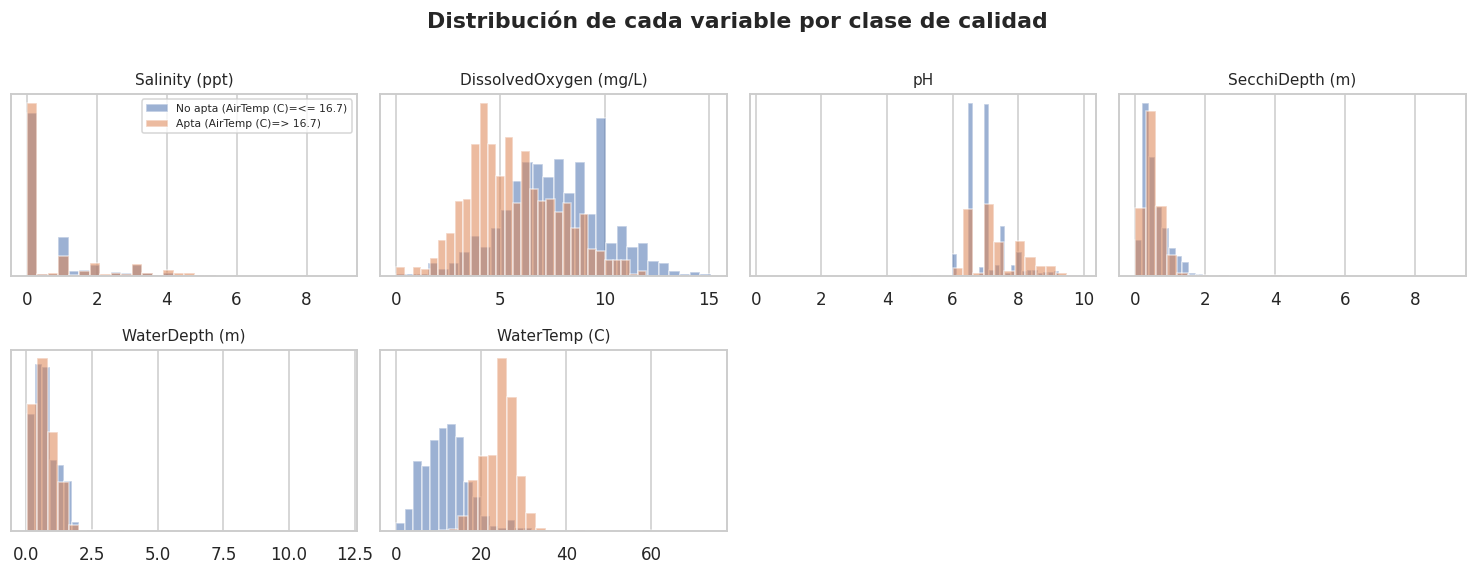

In [ ]:
def rejilla(n, cols=4, alto=2.6, ancho=3.4):
    filas = int(np.ceil(n / cols))
    fig, axes = plt.subplots(filas, cols, figsize=(ancho * cols, alto * filas))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[n:]:
        ax.set_visible(False)
    return fig, axes[:n]


VARS_GRAFICA = CARACTERISTICAS[:24]  # límite para que la rejilla siga siendo legible

fig, axes = rejilla(len(VARS_GRAFICA))
for ax, col in zip(axes, VARS_GRAFICA):
    for k in range(N_CLASES):
        datos = df.loc[y_todo == k, col].dropna()
        ax.hist(datos, bins=30, alpha=0.55, density=True,
                label=NOMBRES_CLASE[k], color=colores_clase(N_CLASES)[k])
    ax.set_title(col, fontsize=10)
    ax.set_yticks([])
axes[0].legend(fontsize=7)
fig.suptitle("Distribución de cada variable por clase de calidad", fontweight="bold", y=1.002)
plt.show()

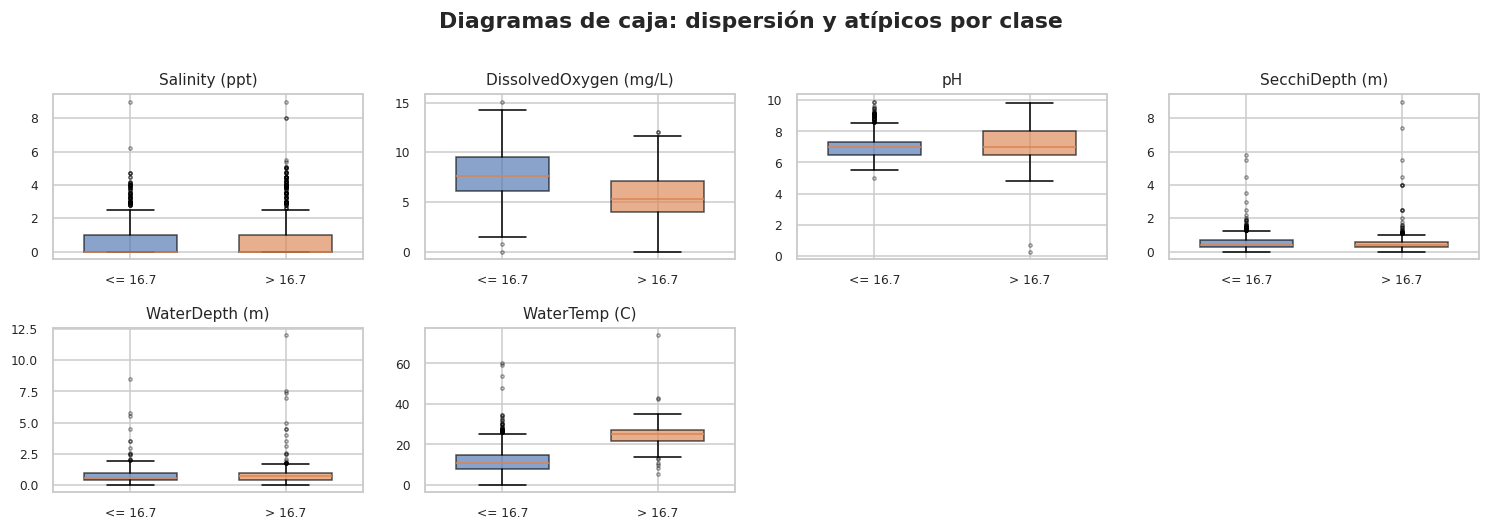

In [ ]:
fig, axes = rejilla(len(VARS_GRAFICA), alto=2.4)
for ax, col in zip(axes, VARS_GRAFICA):
    datos = [df.loc[y_todo == k, col].dropna().values for k in range(N_CLASES)]
    etiquetas = [str(c) for c in CLASES_ORIG]
    try:
        bp = ax.boxplot(datos, tick_labels=etiquetas, patch_artist=True, widths=0.6,
                        flierprops={"markersize": 2, "alpha": 0.4})
    except TypeError:  # matplotlib < 3.9
        bp = ax.boxplot(datos, labels=etiquetas, patch_artist=True, widths=0.6,
                        flierprops={"markersize": 2, "alpha": 0.4})
    for parche, color in zip(bp["boxes"], colores_clase(N_CLASES)):
        parche.set_facecolor(color)
        parche.set_alpha(0.65)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
fig.suptitle("Diagramas de caja: dispersión y atípicos por clase", fontweight="bold", y=1.002)
plt.show()

### 3.4 P3 — ¿Qué variables separan mejor las clases?

Usamos dos medidas complementarias, ambas calculadas a mano:

- **η² (eta cuadrado)**: proporción de la varianza de la variable explicada por la clase. Funciona con
  cualquier número de clases. Convención: 0.01 efecto pequeño, 0.06 medio, 0.14 grande.
- **d de Cohen** (solo si hay 2 clases): diferencia de medias en unidades de desviación estándar.
  Convención: 0.2 pequeño, 0.5 medio, 0.8 grande.
- **Prueba t de Welch**: contrasta H₀ "las medias de ambas clases son iguales". El *p*-valor se aproxima
  con la normal estándar (válido porque n es grande), usando `math.erf` de la librería estándar.

In [ ]:
from math import erf, sqrt


def fdp_normal_acumulada(z):
    """Función de distribución acumulada de la normal estándar (sin scipy)."""
    return 0.5 * (1.0 + erf(z / sqrt(2.0)))


def eta_cuadrado(x, y, k_clases):
    """Proporción de varianza de x explicada por la pertenencia a la clase."""
    mask = ~np.isnan(x)
    x, y = x[mask], y[mask]
    if len(x) < 3:
        return np.nan
    media_global = x.mean()
    sc_entre = sum(((y == k).sum()) * (x[y == k].mean() - media_global) ** 2
                   for k in range(k_clases) if (y == k).sum() > 0)
    sc_total = ((x - media_global) ** 2).sum()
    return sc_entre / sc_total if sc_total > 0 else np.nan


def d_de_cohen_y_welch(x, y):
    """Devuelve (d de Cohen, estadístico t de Welch, p-valor bilateral) para dos clases."""
    mask = ~np.isnan(x)
    x, y = x[mask], y[mask]
    a, b = x[y == 0], x[y == 1]
    if len(a) < 2 or len(b) < 2:
        return np.nan, np.nan, np.nan
    m1, m2 = a.mean(), b.mean()
    v1, v2 = a.var(ddof=1), b.var(ddof=1)
    n1, n2 = len(a), len(b)
    s_combinada = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    d = (m2 - m1) / s_combinada if s_combinada > 0 else np.nan
    error = np.sqrt(v1 / n1 + v2 / n2)
    t = (m2 - m1) / error if error > 0 else np.nan
    p = 2 * (1 - fdp_normal_acumulada(abs(t))) if np.isfinite(t) else np.nan
    return d, t, p


filas = []
for col in CARACTERISTICAS:
    x = df[col].to_numpy(dtype=float)
    fila = {"variable": col, "eta2": eta_cuadrado(x, y_todo, N_CLASES)}
    if N_CLASES == 2:
        d, t, p = d_de_cohen_y_welch(x, y_todo)
        fila.update({"d_cohen": d, "t_welch": t, "p_valor": p,
                     "media_clase0": np.nanmean(x[y_todo == 0]),
                     "media_clase1": np.nanmean(x[y_todo == 1])})
    filas.append(fila)

asociacion = pd.DataFrame(filas).set_index("variable")
asociacion["fuerza"] = pd.cut(asociacion["eta2"].fillna(0),
                              bins=[-1, 0.01, 0.06, 0.14, 1],
                              labels=["insignificante", "pequeño", "medio", "grande"])
asociacion = asociacion.sort_values("eta2", ascending=False)
asociacion.round(4)

,eta2,d_cohen,t_welch,p_valor,media_clase0,media_clase1,fuerza
variable,,,,,,,
WaterTemp (C),0.5903,2.3996,56.9920,0.0000,11.7247,24.4759,grande
DissolvedOxygen (mg/L),0.1677,-0.8971,-17.4760,0.0000,7.6791,5.6269,grande
pH,0.0307,0.3559,8.4744,0.0000,7.0303,7.3070,pequeño
SecchiDepth (m),0.0027,-0.1032,-2.4723,0.0134,0.5496,0.5007,insignificante
Salinity (ppt),0.0017,0.0828,1.9604,0.0499,0.6664,0.7683,insignificante
WaterDepth (m),0.0000,0.0072,0.1714,0.8639,0.7610,0.7654,insignificante


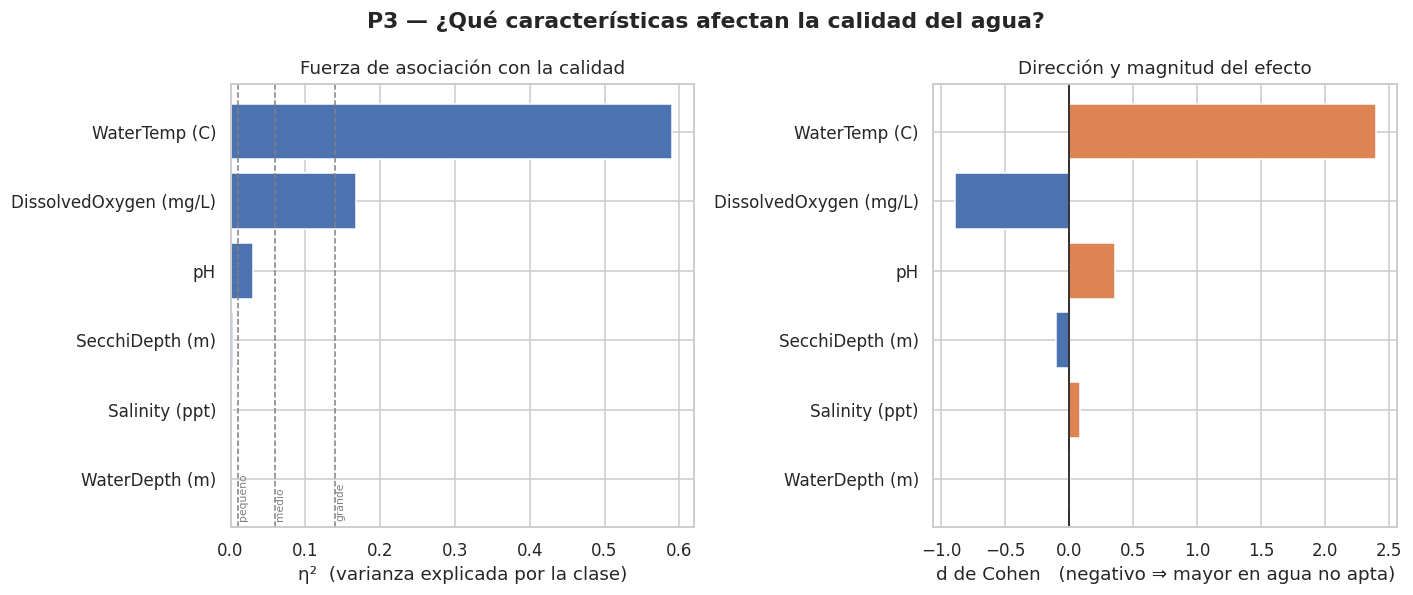

Variables con asociación estadísticamente significativa (p < 0.01): 3 de 6
Las 8 variables más determinantes según el EDA: ['WaterTemp (C)', 'DissolvedOxygen (mg/L)', 'pH', 'SecchiDepth (m)', 'Salinity (ppt)', 'WaterDepth (m)']


In [ ]:
top = asociacion.head(15).iloc[::-1]
fig, axes = plt.subplots(1, 2 if N_CLASES == 2 else 1, figsize=(13 if N_CLASES == 2 else 7, 5.5))
axes = np.atleast_1d(axes)

axes[0].barh(top.index, top["eta2"], color=PALETA["neg"])
axes[0].set_xlabel("η²  (varianza explicada por la clase)")
axes[0].set_title("Fuerza de asociación con la calidad")
for umbral, etiqueta in [(0.01, "pequeño"), (0.06, "medio"), (0.14, "grande")]:
    if top["eta2"].max() > umbral / 2:
        axes[0].axvline(umbral, ls="--", lw=1, color="gray")
        axes[0].text(umbral, -0.6, etiqueta, fontsize=7, color="gray", rotation=90, va="bottom")

if N_CLASES == 2:
    colores = [PALETA["pos"] if v > 0 else PALETA["neg"] for v in top["d_cohen"]]
    axes[1].barh(top.index, top["d_cohen"], color=colores)
    axes[1].axvline(0, color="black", lw=1)
    axes[1].set_xlabel("d de Cohen   (negativo ⇒ mayor en agua no apta)")
    axes[1].set_title("Dirección y magnitud del efecto")

fig.suptitle("P3 — ¿Qué características afectan la calidad del agua?", fontweight="bold")
plt.show()

if N_CLASES == 2 and "p_valor" in asociacion.columns:
    significativas = asociacion[asociacion["p_valor"].fillna(1.0) < 0.01]
else:
    significativas = asociacion[asociacion["eta2"].fillna(0) > 0.01]
print(f"Variables con asociación estadísticamente significativa (p < 0.01): "
      f"{len(significativas)} de {len(CARACTERISTICAS)}")
TOP_VARIABLES = list(asociacion.head(8).index)
print("Las 8 variables más determinantes según el EDA:", TOP_VARIABLES)

### 3.5 P4 — Correlación entre las variables predictoras

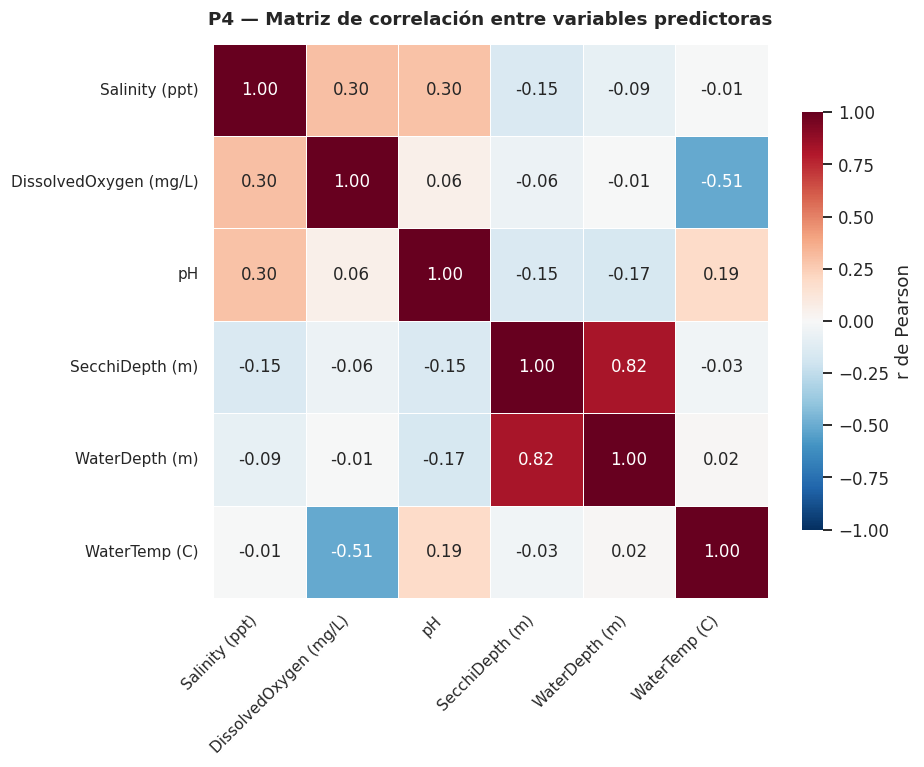

Pares con correlación |r| > 0.7 (posible redundancia):
SecchiDepth (m)  WaterDepth (m)    0.821
dtype: float64

Correlación absoluta media entre predictoras: 0.190 (máxima: 0.821)


In [ ]:
corr = df[CARACTERISTICAS].corr(numeric_only=True)
n = len(CARACTERISTICAS)
lado = max(7, 0.55 * n + 3)          # tamaño mínimo aunque haya pocas variables

fig, ax = plt.subplots(figsize=(lado + 1.5, lado))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.75, "label": "r de Pearson"},
            annot=n <= 12, fmt=".2f", annot_kws={"size": 11 if n <= 8 else 8},
            ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_title("P4 — Matriz de correlación entre variables predictoras",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

triangulo = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
pares_altos = triangulo[triangulo.abs() > 0.7].sort_values(key=abs, ascending=False)
if len(pares_altos):
    print("Pares con correlación |r| > 0.7 (posible redundancia):")
    print(pares_altos.round(3))
else:
    print("No hay pares con |r| > 0.7: no existe multicolinealidad severa.")
print(f"\nCorrelación absoluta media entre predictoras: "
      f"{triangulo.abs().mean():.3f} (máxima: {triangulo.abs().max():.3f})")

### 3.6 P5 — ¿La relación con la calidad es lineal o por umbrales?

Para cada una de las variables más informativas dividimos las muestras en deciles y calculamos la
proporción de agua apta dentro de cada decil. Si la relación fuera lineal veríamos una recta; si hay
**umbrales de toxicidad**, veremos una curva plana que cae (o sube) de golpe.

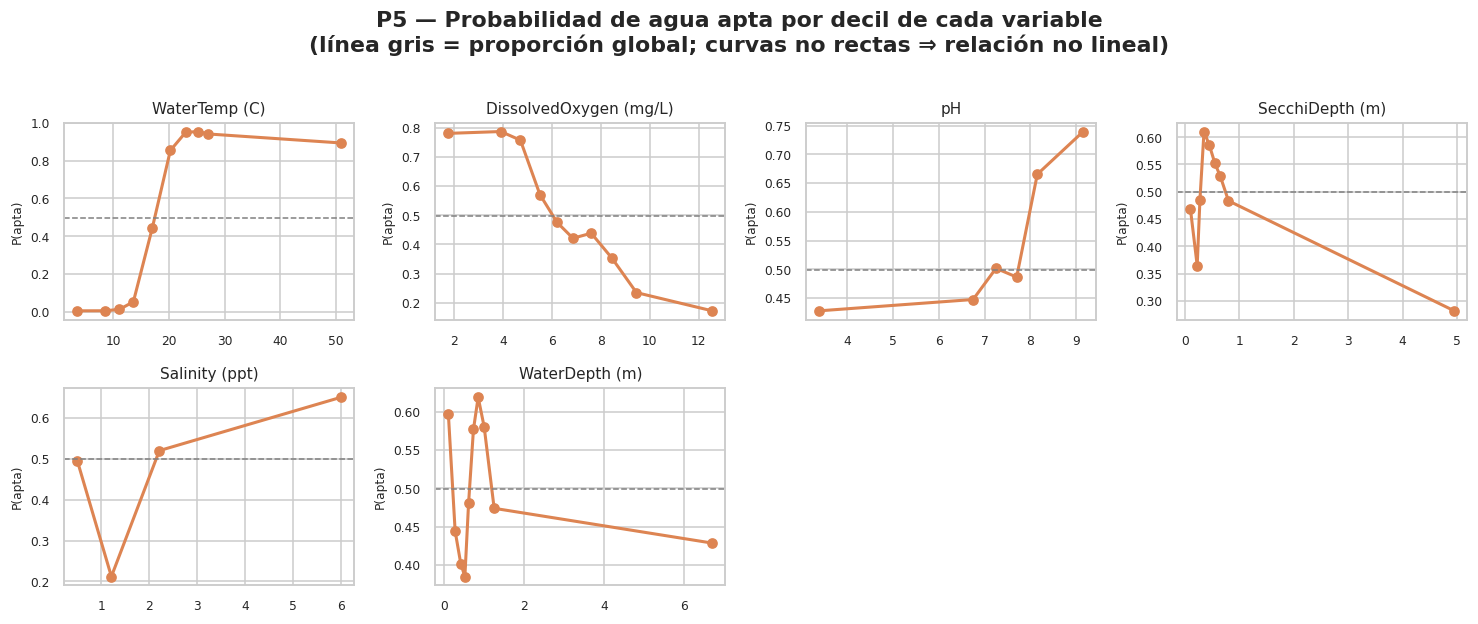

In [ ]:
clase_positiva = N_CLASES - 1
y_bin = (y_todo == clase_positiva).astype(int)

vars_umbral = TOP_VARIABLES[:8]
fig, axes = rejilla(len(vars_umbral), cols=4, alto=2.8)
for ax, col in zip(axes, vars_umbral):
    serie = df[col]
    try:
        deciles = pd.qcut(serie, 10, duplicates="drop")
    except ValueError:
        ax.set_visible(False)
        continue
    tabla = pd.DataFrame({"bin": deciles, "y": y_bin}).dropna().groupby("bin", observed=True)["y"]
    prop, centros = tabla.mean(), [iv.mid for iv in tabla.mean().index]
    ax.plot(centros, prop.values, "o-", color=PALETA["pos"], lw=2)
    ax.axhline(y_bin.mean(), ls="--", color="gray", lw=1)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("P(apta)", fontsize=8)
    ax.tick_params(labelsize=8)
fig.suptitle("P5 — Probabilidad de agua apta por decil de cada variable\n"
             "(línea gris = proporción global; curvas no rectas ⇒ relación no lineal)",
             fontweight="bold", y=1.01)
plt.show()

In [ ]:
# Cuantificamos la no linealidad. Para cada variable comparamos:
#   - r^2  : varianza de la etiqueta explicada por un ajuste LINEAL sobre la variable.
#   - eta^2: varianza de la etiqueta explicada al agrupar la variable en deciles (permite
#            cualquier forma: escalones, curvas en U, umbrales).
# Si eta^2 >> r^2, la relación NO es lineal y un modelo lineal pierde información.
def eta2_por_bins(x, y, n_bins=10):
    mask = ~np.isnan(x)
    x, y = x[mask], y[mask].astype(float)
    if len(x) < 50 or np.std(x) == 0:
        return np.nan, np.nan
    try:
        bins = pd.qcut(pd.Series(x), n_bins, duplicates="drop", labels=False)
    except ValueError:
        return np.nan, np.nan
    media = y.mean()
    sc_total = ((y - media) ** 2).sum()
    if sc_total == 0:
        return np.nan, np.nan
    sc_entre = 0.0
    for b in np.unique(bins.dropna()):
        grupo = y[bins.to_numpy() == b]
        sc_entre += len(grupo) * (grupo.mean() - media) ** 2
    r = np.corrcoef(x, y)[0, 1]
    return r ** 2, sc_entre / sc_total


comparacion = []
for col in CARACTERISTICAS:
    r2, eta2 = eta2_por_bins(df[col].to_numpy(dtype=float), y_bin)
    if np.isnan(r2):
        continue
    comparacion.append({"variable": col, "r² (lineal)": r2, "η² (por deciles)": eta2,
                        "ganancia no lineal": eta2 - r2})
comparacion = pd.DataFrame(comparacion).set_index("variable").sort_values("ganancia no lineal",
                                                                          ascending=False)
print("Varianza de la calidad explicada: ajuste lineal vs. ajuste por deciles (top 10):")
comparacion.head(10).round(4)

Varianza de la calidad explicada: ajuste lineal vs. ajuste por deciles (top 10):


,r² (lineal),η² (por deciles),ganancia no lineal
variable,,,
WaterTemp (C),0.5903,0.7302,0.1399
SecchiDepth (m),0.0027,0.0353,0.0326
WaterDepth (m),0.0000,0.0265,0.0265
pH,0.0307,0.0431,0.0124
Salinity (ppt),0.0017,0.0106,0.0089
DissolvedOxygen (mg/L),0.1677,0.1745,0.0069


### 3.7 Conclusiones del EDA

El resumen que se imprime a continuación se genera a partir de los números calculados arriba, de modo
que sigue siendo válido aunque cambie la versión del dataset.

In [ ]:

print("RESPUESTAS A LAS PREGUNTAS DEL EDA".center(78))

print(f"\nP1 (balance)      : la clase mayoritaria representa el {linea_base:.1%} de las muestras.")
print(f"                    H1 {'SE CONFIRMA' if DESBALANCEADO else 'NO se confirma'}: "
      f"{'hay desbalance, la accuracy sola no basta.' if DESBALANCEADO else 'las clases están razonablemente balanceadas.'}")
print(f"\nP2 (calidad)      : {int(nulos.sum())} valores faltantes "
      f"({nulos.sum() / (len(df) * len(CARACTERISTICAS)):.2%} de las celdas), "
      f"concentrados en {(nulos > 0).sum()} columna(s).")
print(f"                    H2 {'SE CONFIRMA' if (nulos > 0).sum() <= max(3, 0.25 * len(CARACTERISTICAS)) else 'NO se confirma'}: "
      "se imputan con la mediana del conjunto de entrenamiento sin descartar filas.")
print(f"\nP3 (variables)    : {len(significativas)} de {len(CARACTERISTICAS)} variables muestran asociación "
      f"con la calidad.")
print(f"                    Las más determinantes son: {', '.join(TOP_VARIABLES[:5])}.")
if N_CLASES == 2:
    sube = asociacion.head(8)[asociacion.head(8)["d_cohen"] < 0].index.tolist()
    if sube:
        print(f"                    Concentraciones MÁS ALTAS en el agua NO apta: {', '.join(sube[:5])}")
        print("                    => esas variables son las principales causas del deterioro de la calidad.")
print(f"\nP4 (correlación)  : correlación absoluta media entre predictoras = {triangulo.abs().mean():.3f}; "
      f"{len(pares_altos)} par(es) con |r|>0.7.")
print(f"                    H4 {'SE CONFIRMA' if len(pares_altos) <= 3 else 'NO se confirma'}: "
      f"{'sin multicolinealidad severa, se conservan todas las variables.' if len(pares_altos) <= 3 else 'hay redundancia; conviene revisar variables duplicadas.'}")
ganancia_media = comparacion["ganancia no lineal"].head(8).mean()
factor = (comparacion["η² (por deciles)"].head(8).sum()
          / max(comparacion["r² (lineal)"].head(8).sum(), 1e-9))
print(f"\nP5 (no linealidad): agrupando por deciles se explica {factor:.2f} veces más varianza de la "
      f"calidad que con\n                    un ajuste lineal (ganancia media de "
      f"{ganancia_media:+.4f} en varianza explicada).")
print(f"                    H5 {'SE CONFIRMA' if ganancia_media > 0.005 else 'NO se confirma'}: "
      f"{'la relación es no lineal / por umbrales, lo que justifica una red neuronal.' if ganancia_media > 0.005 else 'un modelo lineal podría bastar; la red deberá demostrar que supera al modelo lineal (sección 9.1).'}")


                      RESPUESTAS A LAS PREGUNTAS DEL EDA                      

P1 (balance)      : la clase mayoritaria representa el 50.1% de las muestras.
                    H1 NO se confirma: las clases están razonablemente balanceadas.

P2 (calidad)      : 1310 valores faltantes (9.25% de las celdas), concentrados en 6 columna(s).
                    H2 NO se confirma: se imputan con la mediana del conjunto de entrenamiento sin descartar filas.

P3 (variables)    : 3 de 6 variables muestran asociación con la calidad.
                    Las más determinantes son: WaterTemp (C), DissolvedOxygen (mg/L), pH, SecchiDepth (m), Salinity (ppt).
                    Concentraciones MÁS ALTAS en el agua NO apta: DissolvedOxygen (mg/L), SecchiDepth (m)
                    => esas variables son las principales causas del deterioro de la calidad.

P4 (correlación)  : correlación absoluta media entre predictoras = 0.190; 1 par(es) con |r|>0.7.
                    H4 SE CONFIRMA: sin multicolin

#El dataset es apto para modelado predictivo: las clases están balanceadas, los datos faltantes son manejables, existen variables con poder explicativo claro, no hay problemas de correlación fuerte y la relación con la calidad es no lineal. Esto sugiere que un modelo flexible (como una red neuronal o árboles de decisión) puede capturar mejor los patrones que un modelo lineal clásico.

## 4. Preparación de los datos para la red

Orden de las operaciones (importa, y es una de las preguntas típicas de la sustentación):

1. **Partir primero** 80% / 20%, de forma estratificada.
2. **Después** imputar y estandarizar, calculando mediana y desviación estándar **solo con el 80% de
   entrenamiento** y aplicando esos mismos valores al 20% de validación.

Si se hiciera al revés, la media del conjunto de validación se filtraría al entrenamiento (*data leakage*)
y la evaluación quedaría inflada.

### 4.1 Partición estratificada 80 / 20 (implementada a mano)

In [ ]:
def dividir_entrenamiento_prueba(X, y, prop_entrenamiento=0.8, semilla=42):
    """Partición estratificada: conserva la proporción de clases en ambos conjuntos."""
    generador = np.random.default_rng(semilla)
    idx_entrena, idx_prueba = [], []
    for k in np.unique(y):
        idx_k = np.flatnonzero(y == k)
        generador.shuffle(idx_k)
        corte = int(round(prop_entrenamiento * len(idx_k)))
        idx_entrena.append(idx_k[:corte])
        idx_prueba.append(idx_k[corte:])
    idx_entrena = np.concatenate(idx_entrena)
    idx_prueba = np.concatenate(idx_prueba)
    generador.shuffle(idx_entrena)
    generador.shuffle(idx_prueba)
    return X[idx_entrena], X[idx_prueba], y[idx_entrena], y[idx_prueba]


X_entrena_todo, X_prueba, y_entrena_todo, y_prueba = dividir_entrenamiento_prueba(
    X_todo, y_todo, PROP_ENTRENAMIENTO, SEMILLA)

# Dentro del 80% de entrenamiento apartamos un 15% como validación interna. Sirve para la parada
# temprana y para elegir el umbral de decisión SIN tocar el 20% de prueba, que queda reservado
# exclusivamente para la evaluación final exigida en el parcial.
X_entrena, X_val, y_entrena, y_val = dividir_entrenamiento_prueba(
    X_entrena_todo, y_entrena_todo, 0.85, SEMILLA + 1)

print(f"Total                     : {len(y_todo)} muestras")
print(f"Entrenamiento (80%)       : {len(y_entrena_todo)}  -> de las cuales:")
print(f"   · ajuste de pesos      : {len(y_entrena)}")
print(f"   · validación interna   : {len(y_val)}  (parada temprana y umbral)")
print(f"Prueba / validación (20%) : {len(y_prueba)}  (NO se usa hasta la sección 8)")
print("\nProporción de la clase positiva en cada conjunto (debe ser similar):")
for nombre, yy in [("entrenamiento", y_entrena), ("val. interna", y_val), ("prueba", y_prueba)]:
    print(f"   {nombre:<14}: {(yy == N_CLASES - 1).mean():.3f}")

Total                     : 2361 muestras
Entrenamiento (80%)       : 1888  -> de las cuales:
   · ajuste de pesos      : 1605
   · validación interna   : 283  (parada temprana y umbral)
Prueba / validación (20%) : 473  (NO se usa hasta la sección 8)

Proporción de la clase positiva en cada conjunto (debe ser similar):
   entrenamiento : 0.499
   val. interna  : 0.498
   prueba        : 0.499


### 4.2 Imputación y estandarización (ajustadas solo con entrenamiento)

Estandarizamos con $z = (x - \mu)/\sigma$. Es necesario porque las variables están en escalas muy
distintas (una concentración en mg/L frente a un conteo bacteriano); sin estandarizar, el gradiente estaría
dominado por las variables de mayor magnitud y el entrenamiento sería lento e inestable.

In [ ]:
medianas = np.nanmedian(X_entrena, axis=0)
medianas = np.where(np.isnan(medianas), 0.0, medianas)


def imputar(X):
    X = X.copy()
    indices = np.where(np.isnan(X))
    X[indices] = np.take(medianas, indices[1])
    return X


X_entrena, X_val, X_prueba = imputar(X_entrena), imputar(X_val), imputar(X_prueba)

mu = X_entrena.mean(axis=0)
sigma = X_entrena.std(axis=0)
sigma[sigma == 0] = 1.0


def estandarizar(X):
    return (X - mu) / sigma


X_entrena_s, X_val_s, X_prueba_s = estandarizar(X_entrena), estandarizar(X_val), estandarizar(X_prueba)

print(f"Media de X estandarizado (entrenamiento): {X_entrena_s.mean():.2e}  (≈ 0 ✓)")
print(f"Desviación estándar                     : {X_entrena_s.std():.4f}  (≈ 1 ✓)")
print(f"Media de X estandarizado (prueba)       : {X_prueba_s.mean():+.4f}  "
      "(cercana a 0, pero NO exactamente 0: se usan los parámetros del entrenamiento ✓)")

Media de X estandarizado (entrenamiento): 7.38e-19  (≈ 0 ✓)
Desviación estándar                     : 1.0000  (≈ 1 ✓)
Media de X estandarizado (prueba)       : -0.0210  (cercana a 0, pero NO exactamente 0: se usan los parámetros del entrenamiento ✓)


### 4.3 Pesos de clase para el desbalance

Con clases desbalanceadas, la red puede minimizar el error simplemente prediciendo siempre la clase
mayoritaria. Para evitarlo ponderamos cada muestra en la función de costo con
$w_k = \dfrac{N}{K \cdot N_k}$: las muestras de la clase minoritaria pesan más.

In [ ]:
conteo_entrena = np.array([(y_entrena == k).sum() for k in range(N_CLASES)], dtype=float)
PESOS_CLASE = len(y_entrena) / (N_CLASES * np.maximum(conteo_entrena, 1))
if not DESBALANCEADO:
    PESOS_CLASE = np.ones(N_CLASES)

for k in range(N_CLASES):
    print(f"{NOMBRES_CLASE[k]:<35} n={int(conteo_entrena[k]):>5}   peso={PESOS_CLASE[k]:.3f}")

No apta (AirTemp (C)=<= 16.7)       n=  804   peso=1.000
Apta (AirTemp (C)=> 16.7)           n=  801   peso=1.000
